In [13]:
## ── 1. Imports ───────────────────────────────────────────────────────────────
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from collections import defaultdict

In [14]:
## ── 2. Mesh Generation ───────────────────────────────────────────────────────

def create_mesh(nx: int, ny: int,
                x_min: float = 0.0, x_max: float = 1.0,
                y_min: float = 0.0, y_max: float = 1.0):
    """
    Build a structured P1 triangular mesh on [x_min, x_max] × [y_min, y_max].

    Parameters
    ----------
    nx, ny          : int   — number of subdivisions along x and y.
    x_min, x_max    : float — horizontal domain extent  (default 0 → 1).
    y_min, y_max    : float — vertical   domain extent  (default 0 → 1).

    Returns
    -------
    nodes : ndarray, shape (N, 2)   — node coordinates.
    elems : ndarray, shape (M, 3)   — triangle connectivity (zero-based).
    """
    x = np.linspace(x_min, x_max, nx + 1)
    y = np.linspace(y_min, y_max, ny + 1)
    xx, yy = np.meshgrid(x, y)
    nodes = np.column_stack([xx.ravel(), yy.ravel()])

    def nid(i, j):
        return j * (nx + 1) + i

    elems = []
    for j in range(ny):
        for i in range(nx):
            elems.append([nid(i, j), nid(i + 1, j), nid(i + 1, j + 1)])
            elems.append([nid(i, j), nid(i + 1, j + 1), nid(i, j + 1)])
    return nodes, np.array(elems, dtype=int)


In [15]:
## ── 3. Permeability Field ─────────────────────────────────────────────────────

def kappa_ball(xy, k1: float, k2: float, radius: float = 0.5,
               center: tuple = (0.5, 0.5)):
    """
    Discontinuous permeability: k1 inside a ball, k2 outside.

    Parameters
    ----------
    xy : array-like, shape (..., 2) or (2,)
        Query points.
    k1 : float
        Permeability inside the ball.
    k2 : float
        Permeability outside the ball.
    radius : float
        Radius of the ball (default 0.5).
    center : tuple (cx, cy)
        Centre of the ball (default (0.5, 0.5)).

    Returns
    -------
    ndarray  (or scalar if a single point was passed)
    """
    arr = np.atleast_2d(xy)
    cx, cy = center
    dist2 = (arr[:, 0] - cx) ** 2 + (arr[:, 1] - cy) ** 2
    vals = np.where(dist2 <= radius ** 2, k1, k2)
    return vals if arr.shape[0] > 1 else float(vals[0])


def sample_kappa_on_element(nodes, elem, kappa_fn):
    """Evaluate kappa at the element centroid (1-point quadrature)."""
    centroid = nodes[elem].mean(axis=0)
    return kappa_fn(centroid)

In [16]:
## ── 4. Element Helpers ───────────────────────────────────────────────────────

def elem_gradients_and_area(nodes, elem):
    """
    Compute constant gradient basis functions and area for a P1 triangle.

    Returns
    -------
    grads : ndarray, shape (3, 2)
        grads[i] = gradient of shape function N_i.
    area : float
        Signed area of the triangle (positive if CCW).
    """
    x0, y0 = nodes[elem[0]]
    x1, y1 = nodes[elem[1]]
    x2, y2 = nodes[elem[2]]

    area = 0.5 * ((x1 - x0) * (y2 - y0) - (x2 - x0) * (y1 - y0))

    # Gradients of barycentric coordinates
    dN = np.array([
        [y1 - y2, x2 - x1],
        [y2 - y0, x0 - x2],
        [y0 - y1, x1 - x0],
    ], dtype=float) / (2.0 * area)

    return dN, abs(area)

In [17]:
## ── 5. Stiffness Matrix Assembly ─────────────────────────────────────────────

def assemble_stiffness(nodes, elems, kappa_fn):
    """
    Assemble global stiffness matrix K for the bilinear form
        a(u,v) = ∫_Ω  k(x) ∇u · ∇v  dΩ
    using one-point (centroid) quadrature.

    Parameters
    ----------
    nodes  : ndarray (N, 2)
    elems  : ndarray (M, 3)
    kappa_fn : callable
        kappa_fn(xy) → scalar or array of permeability values.

    Returns
    -------
    K : scipy.sparse.csr_matrix, shape (N, N)
    """
    N = len(nodes)
    K = sp.lil_matrix((N, N))

    for elem in elems:
        dN, area = elem_gradients_and_area(nodes, elem)
        k_val = sample_kappa_on_element(nodes, elem, kappa_fn)

        # Local 3×3 stiffness: K_loc[i,j] = k * (dNi · dNj) * area
        K_loc = k_val * area * (dN @ dN.T)

        for i_loc, i_glob in enumerate(elem):
            for j_loc, j_glob in enumerate(elem):
                K[i_glob, j_glob] += K_loc[i_loc, j_loc]

    return K.tocsr()

In [18]:
## ── 6. Boundary Conditions ───────────────────────────────────────────────────

def get_boundary_edges(elems):
    """
    Return boundary edges as pairs of node indices.
    An edge is on the boundary iff it appears in exactly one element.
    """
    edge_count = defaultdict(int)
    for elem in elems:
        for i in range(3):
            e = tuple(sorted([elem[i], elem[(i + 1) % 3]]))
            edge_count[e] += 1
    return [e for e, cnt in edge_count.items() if cnt == 1]


def apply_neumann(f, nodes, boundary_edges, neumann_fn, tol=1e-12):
    """
    Add Neumann flux contributions to load vector f (in-place).

    Parameters
    ----------
    f              : ndarray (N,)
    nodes          : ndarray (N, 2)
    boundary_edges : list of (i, j) node-index pairs
    neumann_fn     : callable — neumann_fn(mid_pt, tol) → float flux value.
                     Return 0.0 to skip that edge.
    tol            : float
    """
    for (i, j) in boundary_edges:
        pi, pj = nodes[i], nodes[j]
        mid = 0.5 * (pi + pj)
        g = neumann_fn(mid, tol=tol)
        if g == 0.0:
            continue
        edge_len = np.linalg.norm(pj - pi)
        f[i] += g * edge_len * 0.5
        f[j] += g * edge_len * 0.5


def make_neumann_top_bottom(y_min: float, y_max: float, flux: float = 1.0):
    """
    Return a Neumann function that applies `flux` on the top and bottom
    boundaries (y = y_min or y = y_max) and 0 elsewhere.

    Parameters
    ----------
    y_min, y_max : float — domain y-extents.
    flux         : float — prescribed outward flux value (default 1.0).
    """
    def neumann_fn(mid, tol=1e-12):
        y = mid[1]
        if np.isclose(y, y_min, atol=tol) or np.isclose(y, y_max, atol=tol):
            return flux
        return 0.0
    return neumann_fn


def make_dirichlet_left_right(x_min: float, x_max: float,
                               v_left: float = 0.0, v_right: float = 1.0):
    """
    Return a Dirichlet function that sets v = v_left on x = x_min (left)
    and v = v_right on x = x_max (right).

    Parameters
    ----------
    x_min, x_max   : float — domain x-extents.
    v_left, v_right: float — prescribed values (defaults 0 and 1).
    """
    def dirichlet_fn(xy, tol=1e-12):
        x = xy[0]
        if np.isclose(x, x_min, atol=tol):
            return True, v_left
        if np.isclose(x, x_max, atol=tol):
            return True, v_right
        return False, 0.0
    return dirichlet_fn


def apply_dirichlet(K, f, nodes, dirichlet_fn, tol=1e-12):
    """
    Enforce Dirichlet BCs by row/column elimination (symmetric modification).

    Parameters
    ----------
    K            : lil_matrix or csr_matrix
    f            : ndarray (N,)
    nodes        : ndarray (N, 2)
    dirichlet_fn : callable — dirichlet_fn(xy, tol) → (bool, float)
    tol          : float

    Returns
    -------
    K : csr_matrix,  f : ndarray,  dirichlet_nodes : list[int]
    """
    K_lil = K.tolil()
    dirichlet_nodes = []
    dirichlet_vals  = {}

    for i, xy in enumerate(nodes):
        is_dir, val = dirichlet_fn(xy, tol=tol)
        if is_dir:
            dirichlet_nodes.append(i)
            dirichlet_vals[i] = val

    for i in dirichlet_nodes:
        val = dirichlet_vals[i]
        col = K_lil.getcol(i).toarray().ravel()
        f -= col * val
        K_lil[i, :] = 0.0
        K_lil[:, i] = 0.0
        K_lil[i, i] = 1.0
        f[i] = val

    return K_lil.tocsr(), f, dirichlet_nodes


In [19]:
## ── 7. Linear System Solver ──────────────────────────────────────────────────

def solve_system(K, f, solver: str = "direct"):
    """
    Solve K u = f.

    Parameters
    ----------
    K      : csr_matrix
    f      : ndarray
    solver : str
        'direct'  → spla.spsolve  (robust, good for moderate N)
        'cg'      → conjugate gradient with ILU preconditioner

    Returns
    -------
    u : ndarray
    """
    if solver == "direct":
        return spla.spsolve(K, f)
    elif solver == "cg":
        ilu = spla.spilu(K.tocsc())
        M = spla.LinearOperator(K.shape, ilu.solve)
        u, info = spla.cg(K, f, M=M, tol=1e-10, maxiter=5000)
        if info != 0:
            raise RuntimeError(f"CG did not converge (info={info})")
        return u
    else:
        raise ValueError(f"Unknown solver '{solver}'")

In [20]:
## ── 8. Visualisation ─────────────────────────────────────────────────────────

def plot_solution(nodes, elems, u, kappa_fn=None,
                  ball_center=(0.5, 0.5), ball_radius=0.5,
                  title="Darcy pressure field"):
    """
    Plot the FEM pressure solution on the triangular mesh.
    Optionally overlay the permeability discontinuity circle.
    """
    tri = mtri.Triangulation(nodes[:, 0], nodes[:, 1], elems)

    fig, ax = plt.subplots(figsize=(6, 5))
    tcf = ax.tricontourf(tri, u, levels=40, cmap="RdYlBu_r")
    ax.triplot(tri, color="k", linewidth=0.2, alpha=0.3)
    fig.colorbar(tcf, ax=ax, label="pressure v")

    if kappa_fn is not None:
        theta = np.linspace(0, 2 * np.pi, 300)
        cx, cy = ball_center
        ax.plot(cx + ball_radius * np.cos(theta),
                cy + ball_radius * np.sin(theta),
                "w--", linewidth=1.5, label=f"r={ball_radius} interface")
        ax.legend(loc="upper right", fontsize=8)

    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.tight_layout()
    plt.show()


def plot_permeability(nodes, elems, kappa_fn, title="Permeability k(x)"):
    """Visualise the permeability field on the mesh."""
    centroids = nodes[elems].mean(axis=1)
    k_vals = kappa_fn(centroids)

    tri = mtri.Triangulation(nodes[:, 0], nodes[:, 1], elems)
    fig, ax = plt.subplots(figsize=(5, 5))
    tcf = ax.tripcolor(tri, facecolors=k_vals, cmap="viridis")
    fig.colorbar(tcf, ax=ax, label="k(x)")
    ax.set_aspect("equal")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## 9. Full Pipeline Run

Assemble and solve the complete Darcy problem with ball-inclusion permeability.

Mesh: 40401 nodes, 80000 elements  on [-1.0,1.0]×[-1.0,1.0]


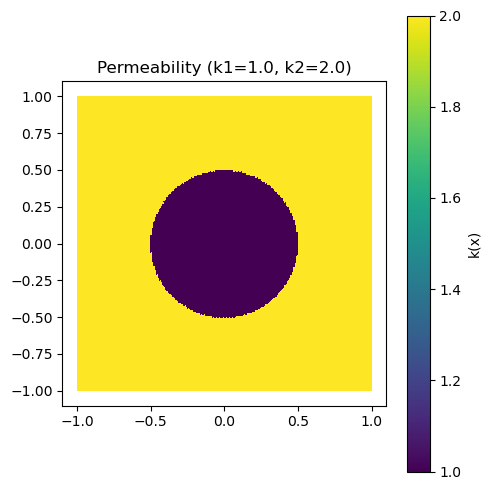

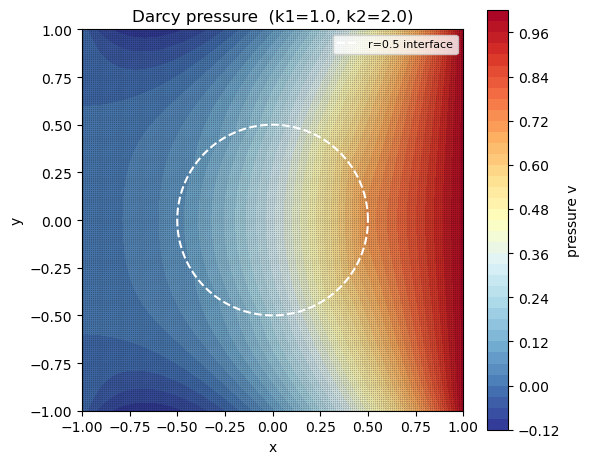

In [22]:
## ── 9. Run ───────────────────────────────────────────────────────────────────

# ── Domain parameters  (change freely) ──────────────────────────────────────
X_MIN, X_MAX = -1.0, 1.0
Y_MIN, Y_MAX = -1.0, 1.0
nx, ny       = 200, 200

# ── Physics parameters ────────────────────────────────────────────────────────
K1, K2   = 1.0, 2.0
RADIUS   = 0.5
CENTER   = (0.5 * (X_MIN + X_MAX), 0.5 * (Y_MIN + Y_MAX))  # domain centre
V_LEFT, V_RIGHT = 0.0, 1.0
NEUMANN_FLUX    = -1.0   # prescribed outward flux on top/bottom — matches PINN h(x)=-1

# ── Build mesh ────────────────────────────────────────────────────────────────
nodes, elems = create_mesh(nx, ny, X_MIN, X_MAX, Y_MIN, Y_MAX)
print(f"Mesh: {len(nodes)} nodes, {len(elems)} elements  "
      f"on [{X_MIN},{X_MAX}]×[{Y_MIN},{Y_MAX}]")

# ── Define permeability ───────────────────────────────────────────────────────
kappa = lambda xy: kappa_ball(xy, k1=K1, k2=K2, radius=RADIUS, center=CENTER)
plot_permeability(nodes, elems, kappa, title=f"Permeability (k1={K1}, k2={K2})")

# ── Build BC functions from domain parameters ─────────────────────────────────
neumann_fn   = make_neumann_top_bottom(Y_MIN, Y_MAX, flux=NEUMANN_FLUX)
dirichlet_fn = make_dirichlet_left_right(X_MIN, X_MAX, V_LEFT, V_RIGHT)

# ── Assemble ──────────────────────────────────────────────────────────────────
K_global = assemble_stiffness(nodes, elems, kappa)
f_global = np.zeros(len(nodes))

bnd_edges = get_boundary_edges(elems)
apply_neumann(f_global, nodes, bnd_edges, neumann_fn)
K_global, f_global, _ = apply_dirichlet(K_global, f_global, nodes, dirichlet_fn)

# ── Solve ─────────────────────────────────────────────────────────────────────
u = solve_system(K_global, f_global, solver="direct")

# ── Visualise ─────────────────────────────────────────────────────────────────
plot_solution(nodes, elems, u, kappa_fn=kappa,
              ball_center=CENTER, ball_radius=RADIUS,
              title=f"Darcy pressure  (k1={K1}, k2={K2})")


## 10. Residual Test

Verify solution quality:
1. **Algebraic residual** $\|K u - f\| / \|f\|$ — should be near machine epsilon for a direct solver.
2. **Dirichlet BC check** — left nodes $\approx 0$, right nodes $\approx 1$.
3. **Element-wise strong residual** — indicator of local accuracy.

In [ ]:
## ── 10. Residual Tests ───────────────────────────────────────────────────────

def compute_algebraic_residual(K, f, u):
    """Relative residual ||Ku - f|| / ||f||."""
    r = K @ u - f
    return np.linalg.norm(r) / (np.linalg.norm(f) + 1e-300)


def check_dirichlet_bcs(u, nodes, dirichlet_fn, tol=1e-12):
    """Return max absolute error at Dirichlet nodes."""
    errs = []
    for i, xy in enumerate(nodes):
        is_dir, val = dirichlet_fn(xy, tol=tol)
        if is_dir:
            errs.append(abs(u[i] - val))
    return max(errs) if errs else 0.0


def compute_element_residuals(nodes, elems, u, kappa_fn):
    """
    Element-wise flux-jump residual: ||[[k ∇u · n]]||_{L1, edges}.
    For P1 elements the interior PDE residual is zero; the relevant
    indicator is the normal-flux jump across each interior edge.
    """
    edge_elems = defaultdict(list)
    for eid, elem in enumerate(elems):
        for i in range(3):
            e = tuple(sorted([elem[i], elem[(i + 1) % 3]]))
            edge_elems[e].append(eid)

    flux = []
    for elem in elems:
        dN, _ = elem_gradients_and_area(nodes, elem)
        k_val = sample_kappa_on_element(nodes, elem, kappa_fn)
        flux.append(k_val * (dN.T @ u[elem]))
    flux = np.array(flux)

    jump_res = np.zeros(len(elems))
    for (i, j), eids in edge_elems.items():
        if len(eids) == 2:
            pi, pj = nodes[i], nodes[j]
            edge_len = np.linalg.norm(pj - pi)
            normal = np.array([pj[1] - pi[1], pi[0] - pj[0]])
            normal /= np.linalg.norm(normal)
            jump = abs((flux[eids[0]] - flux[eids[1]]) @ normal) * edge_len
            jump_res[eids[0]] += jump
            jump_res[eids[1]] += jump
    return jump_res


# ── Build post-BC system to test against ─────────────────────────────────────
K_check = assemble_stiffness(nodes, elems, kappa)
f_check = np.zeros(len(nodes))
apply_neumann(f_check, nodes, bnd_edges, neumann_fn)
K_check, f_check, _ = apply_dirichlet(K_check, f_check, nodes, dirichlet_fn)

# 1 — Algebraic residual
alg_res = compute_algebraic_residual(K_check, f_check, u)
print(f"Relative algebraic residual (post-BC): {alg_res:.3e}")

# 2 — Dirichlet BC satisfaction
dir_err = check_dirichlet_bcs(u, nodes, dirichlet_fn)
print(f"Max Dirichlet BC error:                {dir_err:.3e}")

# 3 — Element jump residuals
jump_res = compute_element_residuals(nodes, elems, u, kappa)
print(f"Element jump residual — max : {jump_res.max():.3e}")
print(f"                       mean : {jump_res.mean():.3e}")
print(f"                       L2   : {np.sqrt((jump_res**2).sum()):.3e}")

# Pass / fail
assert alg_res < 1e-8,  f"Algebraic residual too large: {alg_res:.3e}"
assert dir_err < 1e-10, f"Dirichlet BC error too large: {dir_err:.3e}"
print("\n✓ All residual tests passed.")


Relative algebraic residual (post-BC): 2.264e-15
Max Dirichlet BC error:                0.000e+00
Element jump residual — max : 4.366e-02
                       mean : 1.497e-03
                       L2   : 3.559e-01

✓ All residual tests passed.


## 11. Export Solution to HDF5

Sample ~10 000 uniformly-distributed query points across the domain, interpolate
the FEM solution at each point via barycentric coordinates, and save everything
to an HDF5 file for downstream use.

In [ ]:
## ── 11. Export Solution to HDF5 ──────────────────────────────────────────────
import h5py
from scipy.interpolate import LinearNDInterpolator

# ── 1. Generate ~10 000 linearly-spaced sample points ────────────────────────
N_SAMPLES = 10_000                          # exact count after rounding
n_side = int(np.sqrt(N_SAMPLES))            # grid points per side (~100)
xs = np.linspace(X_MIN, X_MAX, n_side)
ys = np.linspace(Y_MIN, Y_MAX, n_side)
gx, gy = np.meshgrid(xs, ys)
sample_pts = np.column_stack([gx.ravel(), gy.ravel()])   # (n_side², 2)
print(f"Sampling {len(sample_pts)} points on a {n_side}×{n_side} grid")

# ── 2. Interpolate FEM solution at sample points ──────────────────────────────
#    LinearNDInterpolator uses a Delaunay triangulation of the FEM nodes and
#    performs barycentric interpolation — consistent with P1 elements.
interp = LinearNDInterpolator(nodes, u)
u_sampled = interp(sample_pts)              # NaN for any point outside the mesh

# Sanity check: fraction of points with valid values
n_valid = np.sum(~np.isnan(u_sampled))
print(f"Valid interpolated values: {n_valid}/{len(sample_pts)}")

# ── 3. Evaluate permeability at sample points ─────────────────────────────────
k_sampled = kappa(sample_pts)               # uses the kappa_ball lambda from run cell

# ── 4. Write HDF5 file ────────────────────────────────────────────────────────
HDF5_PATH = "darcy_solution.h5"

with h5py.File(HDF5_PATH, "w") as f:
    # ── metadata ────────────────────────────────────────────────────────────
    meta = f.create_group("metadata")
    meta.attrs["domain"]        = f"[{X_MIN},{X_MAX}]x[{Y_MIN},{Y_MAX}]"
    meta.attrs["nx"]            = nx
    meta.attrs["ny"]            = ny
    meta.attrs["n_fem_nodes"]   = len(nodes)
    meta.attrs["n_fem_elems"]   = len(elems)
    meta.attrs["k1"]            = K1
    meta.attrs["k2"]            = K2
    meta.attrs["ball_radius"]   = RADIUS
    meta.attrs["ball_center"]   = CENTER
    meta.attrs["v_left"]        = V_LEFT
    meta.attrs["v_right"]       = V_RIGHT
    meta.attrs["neumann_flux"]  = NEUMANN_FLUX

    # ── FEM mesh and nodal solution ─────────────────────────────────────────
    fem = f.create_group("fem")
    fem.create_dataset("nodes",    data=nodes,  compression="gzip")
    fem.create_dataset("elements", data=elems,  compression="gzip")
    fem.create_dataset("u",        data=u,      compression="gzip")

    # ── sampled data ─────────────────────────────────────────────────────────
    samp = f.create_group("samples")
    samp.attrs["n_points"]  = len(sample_pts)
    samp.attrs["grid_size"] = n_side
    samp.create_dataset("xy",          data=sample_pts, compression="gzip")
    samp.create_dataset("u_interp",    data=u_sampled,  compression="gzip")
    samp.create_dataset("kappa",       data=k_sampled,  compression="gzip")

print(f"\nSaved → {HDF5_PATH}")

# ── 5. Quick verification: read back and check ────────────────────────────────
with h5py.File(HDF5_PATH, "r") as f:
    xy_rb  = f["samples/xy"][:]
    u_rb   = f["samples/u_interp"][:]
    k_rb   = f["samples/kappa"][:]
    print(f"Read back:  xy {xy_rb.shape},  u {u_rb.shape},  k {k_rb.shape}")
    print(f"u range: [{np.nanmin(u_rb):.4f}, {np.nanmax(u_rb):.4f}]")
    print(f"k values present: {np.unique(k_rb)}")


Sampling 10000 points on a 100×100 grid
Valid interpolated values: 10000/10000

Saved → darcy_solution.h5
Read back:  xy (10000, 2),  u (10000,),  k (10000,)
u range: [-0.1114, 1.0000]
k values present: [1. 2.]


Flux appended to darcy_solution.h5  —  shape: (10000, 2)
  v_x range: [-3.4887, 1.6090]
  v_y range: [-0.9792, 0.9772]


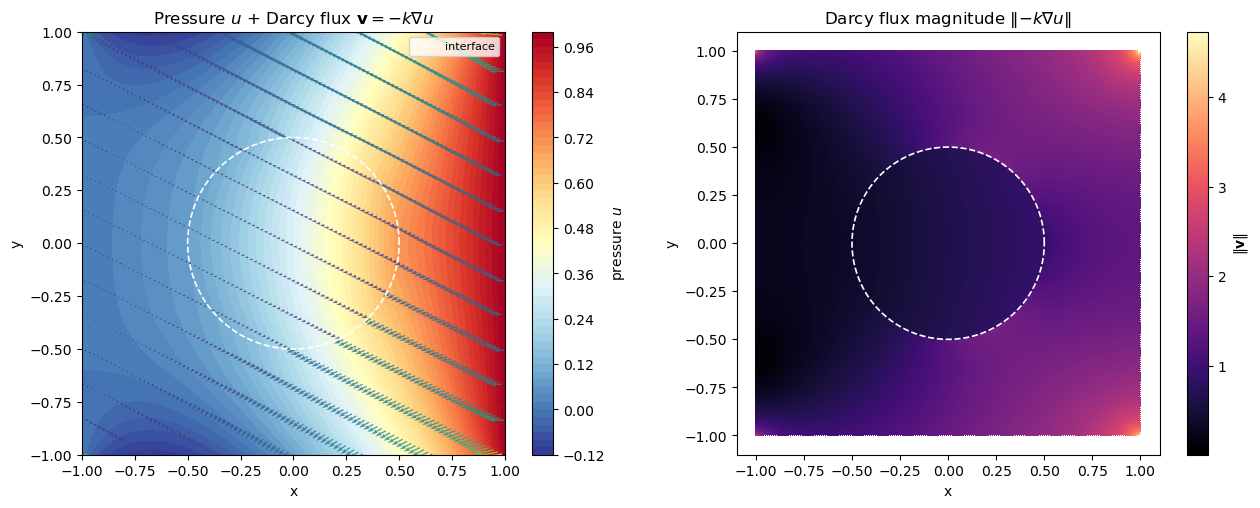

Flux magnitude — min: 0.0041  max: 4.7309  mean: 1.0242


In [25]:
## ── 12. Darcy Flux Field  v = -k ∇u ─────────────────────────────────────────

def compute_flux(nodes, elems, u, kappa_fn):
    """
    Compute Darcy flux v = -k ∇u at each element centroid.
    For P1 elements ∇u is constant per triangle.

    Returns
    -------
    centroids : ndarray (M, 2)
    flux      : ndarray (M, 2)   — v = -k ∇u
    """
    centroids = nodes[elems].mean(axis=1)       # (M, 2)
    flux = np.zeros((len(elems), 2))
    for idx, elem in enumerate(elems):
        dN, _ = elem_gradients_and_area(nodes, elem)
        grad_u = dN.T @ u[elem]                 # (2,)  ∇u on this element
        k_val  = kappa_fn(centroids[idx])
        flux[idx] = -k_val * grad_u
    return centroids, flux


centroids, flux = compute_flux(nodes, elems, u, kappa)

# ── Interpolate flux to the sample grid and append to HDF5 ───────────────────
from scipy.interpolate import LinearNDInterpolator

interp_vx = LinearNDInterpolator(centroids, flux[:, 0])
interp_vy = LinearNDInterpolator(centroids, flux[:, 1])

flux_x_sampled = interp_vx(sample_pts)   # (N,)
flux_y_sampled = interp_vy(sample_pts)   # (N,)
flux_sampled   = np.column_stack([flux_x_sampled, flux_y_sampled])  # (N, 2)

with h5py.File(HDF5_PATH, "a") as f:
    samp = f["samples"]
    # overwrite if already present (re-run safe)
    for key in ("flux_interp",):
        if key in samp:
            del samp[key]
    samp.create_dataset("flux_interp", data=flux_sampled, compression="gzip")

print(f"Flux appended to {HDF5_PATH}  —  shape: {flux_sampled.shape}")
print(f"  v_x range: [{np.nanmin(flux_x_sampled):.4f}, {np.nanmax(flux_x_sampled):.4f}]")
print(f"  v_y range: [{np.nanmin(flux_y_sampled):.4f}, {np.nanmax(flux_y_sampled):.4f}]")

# ── Subsample for a readable quiver plot ─────────────────────────────────────
stride = max(1, len(elems) // 1_200)       # keep ~1200 arrows
c  = centroids[::stride]
fq = flux[::stride]

# ── Plot ──────────────────────────────────────────────────────────────────────
tri = mtri.Triangulation(nodes[:, 0], nodes[:, 1], elems)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: pressure + flux arrows
ax = axes[0]
tcf = ax.tricontourf(tri, u, levels=60, cmap="RdYlBu_r")
fig.colorbar(tcf, ax=ax, label="pressure $u$")
speed = np.linalg.norm(fq, axis=1)
ax.quiver(c[:, 0], c[:, 1], fq[:, 0], fq[:, 1],
          speed, cmap="viridis", scale=None, width=0.003, alpha=0.8)
theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(CENTER[0] + RADIUS * np.cos(theta),
        CENTER[1] + RADIUS * np.sin(theta),
        "w--", lw=1.2, label="interface")
ax.set_aspect("equal"); ax.set_title(r"Pressure $u$ + Darcy flux $\mathbf{v}=-k\nabla u$")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(fontsize=8)

# Right: flux magnitude ||v||
mag = np.linalg.norm(flux, axis=1)
ax2 = axes[1]
tcf2 = ax2.tripcolor(tri, facecolors=mag, cmap="magma")
fig.colorbar(tcf2, ax=ax2, label=r"$\|\mathbf{v}\|$")
ax2.set_aspect("equal"); ax2.set_title(r"Darcy flux magnitude $\|{-k\nabla u}\|$")
ax2.set_xlabel("x"); ax2.set_ylabel("y")
ax2.plot(CENTER[0] + RADIUS * np.cos(theta),
         CENTER[1] + RADIUS * np.sin(theta),
         "w--", lw=1.2)

plt.tight_layout()
plt.show()

print(f"Flux magnitude — min: {mag.min():.4f}  max: {mag.max():.4f}  mean: {mag.mean():.4f}")
